# 10 — So sánh model (LightGBM vs XGBoost) + bộ metric cho fraud mất cân bằng

**Mục tiêu 2 phần:**
1. Trên **cùng một bộ feature PIT-safe** và **cùng một temporal split**, so hai model boosting: LightGBM (họ đã khóa, ADR-003) vs XGBoost (learning baseline, *không promotable*).
2. Học **metric nào phù hợp** cho bài toán fraud cực mất cân bằng và **tại sao** — đi từ những gì bạn đã biết (log loss + confusion matrix) ra tới các metric nghiệp vụ (precision@k, recall@FPR).

> **Exploratory / non-promotable** (giống vai RF trong plan Sprint 3). XGBoost ở đây chỉ để *học so sánh*, không thay LightGBM. Nặng nên gate sau `RUN_COMPARISON` để verify notebook vẫn nhanh & output-free (AGENTS §13).

**Bộ feature dùng:** lõi PIT-safe 7 feature từ ablation notebook 09 (đã bỏ `event_step` vì overfit thời gian). Kết luận so-model không phụ thuộc việc chọn 7 hay 11 feature.

📖 **Cell dưới — Setup.** Import; resolve đường dẫn PaySim/Gold/labels (y hệt notebook 09). Định nghĩa 3 bộ feature: `PIT12` (đủ 12), `PIT_MINUS_EVENTSTEP` (11, bỏ đúng feature overfit), `DEPLOYABLE_CORE` (7 lõi tự tin). In `READY`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from pit_fintech.config import get_settings
from pit_fintech.data.paysim import connect_paysim, find_paysim_csv, resolve_project_root
from pit_fintech.features.paysim_specs import PAYSIM_MODEL_FEATURE_ORDER

PIT12 = list(PAYSIM_MODEL_FEATURE_ORDER)
PIT_MINUS_EVENTSTEP = [f for f in PIT12 if f != "event_step"]
DEPLOYABLE_CORE = [
    "current_amount",
    "transaction_type_transfer",
    "pit_prior_amount_1h",
    "pit_prior_amount_24h",
    "pit_prior_amount_168h",
    "pit_prior_count_1h",
    "pit_prior_count_24h",
]
assert all(f in PIT12 for f in DEPLOYABLE_CORE), "core feature name drift vs contract"

PROJECT_ROOT = resolve_project_root(Path.cwd())
settings = get_settings()
data_root = settings.data_root
if not data_root.is_absolute():
    data_root = PROJECT_ROOT / data_root
artifact_root = settings.artifact_root
if not artifact_root.is_absolute():
    artifact_root = PROJECT_ROOT / artifact_root

paysim_csv = find_paysim_csv(PROJECT_ROOT)
gold_base = data_root / "lakehouse" / "paysim1"
gold_candidates = (
    sorted(gold_base.glob("*/gold/pre_decision_features")) if gold_base.exists() else []
)
GOLD_PRE_PATH = next((p for p in gold_candidates if (p / "_delta_log").exists()), None)

LABELS_PATH = None
try:
    from pit_fintech.data.paysim_lakehouse import (
        ApplicationLakehouseManifest,
        _resolve_manifest_path,
        find_latest_paysim_lakehouse_manifest,
    )

    manifest_path = find_latest_paysim_lakehouse_manifest(artifact_root)
    if manifest_path is not None:
        manifest = ApplicationLakehouseManifest.model_validate_json(
            manifest_path.read_text(encoding="utf-8")
        )
        for snap in manifest.tables:
            if snap.table == "paysim_labels":
                LABELS_PATH = _resolve_manifest_path(snap.path, PROJECT_ROOT)
                break
except Exception as exc:  # optional context, never a gate
    print(f"label resolution skipped: {exc}")

READY = (
    paysim_csv is not None
    and GOLD_PRE_PATH is not None
    and LABELS_PATH is not None
    and (LABELS_PATH / "_delta_log").exists()
)
print({"gold_pre": GOLD_PRE_PATH is not None, "labels": LABELS_PATH is not None, "ready": READY})

{'gold_pre': True, 'labels': True, 'ready': True}


## Execution control
Load dữ liệu + train 2 model là opt-in. Giữ `RUN_COMPARISON = False` để verify nhanh, output-free; đặt `True` khi chạy thật.

In [2]:
RUN_COMPARISON = True
SEED = 20_260_727
FEATURES = DEPLOYABLE_CORE  # đổi sang PIT_MINUS_EVENTSTEP (11) hoặc PIT12 để đối chiếu
print(f"feature set = {len(FEATURES)} cột: {FEATURES}")

feature set = 7 cột: ['current_amount', 'transaction_type_transfer', 'pit_prior_amount_1h', 'pit_prior_amount_24h', 'pit_prior_amount_168h', 'pit_prior_count_1h', 'pit_prior_count_24h']


## Phần A · Dữ liệu & tách split

📖 **Vì sao TEMPORAL split, không random?** Bài toán này là *dự đoán tương lai từ quá khứ*. Nếu trộn ngẫu nhiên (random split), một số giao dịch tương lai lọt vào train → model "thấy trước" pattern của tương lai → điểm đẹp giả, **không phản ánh production**. Temporal split (train quá khứ → test tương lai) mô phỏng đúng lúc deploy, và khớp bất biến PIT.

Ta chia **3 phần theo `step`**:
- **train** `step ≤ 520` — để *fit* model.
- **val** `521 ≤ step ≤ 631` — để *chọn ngưỡng* (threshold) và so model. **Không bao giờ** đụng test khi tinh chỉnh.
- **test** `step ≥ 632` — chỉ *báo cáo một lần*.

📖 **Cell dưới — Nạp `frame`** (DuckDB join có `ORDER BY` để tái lập, giống notebook 09 sau khi fix).

In [3]:
frame = None
if RUN_COMPARISON and READY:
    from deltalake import DeltaTable

    gold = DeltaTable(str(GOLD_PRE_PATH)).to_pyarrow_table()
    labels = (
        DeltaTable(str(LABELS_PATH)).to_pyarrow_table().select(["source_row_number", "isFraud"])
    )
    connection = connect_paysim(paysim_csv)
    connection.register("gold", gold)
    connection.register("labels", labels)
    pit_cols = ", ".join(f"g.{name}" for name in PIT12)
    frame = connection.execute(
        f"SELECT g.source_row_number, g.step, l.isFraud, {pit_cols} "
        "FROM gold AS g "
        "JOIN labels AS l USING (source_row_number) "
        "ORDER BY g.source_row_number"
    ).df()
    connection.close()
    frame[PIT12] = frame[PIT12].astype("float64")
    print(f"rows={len(frame):,}  fraud={int(frame['isFraud'].sum()):,}")
else:
    print("Skipped: set RUN_COMPARISON = True (and ensure data is ready).")

rows=2,770,409  fraud=8,213


📖 **Cell dưới — Dựng 3 split theo thời gian** và in kích thước + tỷ lệ fraud mỗi phần. Chú ý prevalence (tỷ lệ fraud) cực thấp ở cả 3 → đây là gốc rễ của mọi lựa chọn metric phía sau.

In [4]:
splits = None
if frame is not None:
    train_df = frame[frame["step"] <= 520]
    val_df = frame[(frame["step"] >= 521) & (frame["step"] <= 631)]
    test_df = frame[frame["step"] >= 632]
    splits = {"train": train_df, "val": val_df, "test": test_df}
    rows = []
    for name, part in splits.items():
        pos = int((part["isFraud"] == 1).sum())
        rows.append(
            {
                "split": name,
                "rows": len(part),
                "fraud": pos,
                "prevalence": round(pos / max(len(part), 1), 6),
            }
        )
    display(pd.DataFrame(rows))
else:
    print("Skipped: enable RUN_COMPARISON above.")

,split,rows,fraud,prevalence
0,train,2653729,5781,0.002178
1,val,78701,1180,0.014993
2,test,37979,1252,0.032966


## Phần B · Huấn luyện 2 model

📖 **Cell dưới — Train LightGBM + XGBoost CÔNG BẰNG trên cùng feature/split.** Hai chỉnh để so đúng (không phải so config mặc định lệch nhau):
- **`scale_pos_weight = sqrt(neg/pos) ≈ 21`** (thay vì `neg/pos ≈ 458` gây bão hoà xác suất ở LightGBM) — áp **giống hệt** cho cả hai model.
- **`reg_lambda = 1.0`** cho *cả hai* — khớp L2 (LightGBM mặc định 0, XGBoost mặc định 1).

XGBoost chưa có trong deps → import graceful. Kết quả: dict `proba[model][split]` = xác suất fraud.

In [5]:
proba = {}
models = {}
if splits is not None:
    import lightgbm as lgb

    pos = int((train_df["isFraud"] == 1).sum())
    neg = int((train_df["isFraud"] == 0).sum())
    # So CONG BANG: cung imbalance weight vua phai (sqrt thay vi neg/pos~458 gay bao hoa),
    # va khop L2 giua 2 thu vien (LightGBM mac dinh reg_lambda=0, XGBoost lambda=1).
    spw = float(np.sqrt(neg / max(pos, 1)))
    REG_LAMBDA = 1.0
    Xtr, ytr = train_df[FEATURES], train_df["isFraud"]

    lgbm = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=50,
        reg_lambda=REG_LAMBDA,
        scale_pos_weight=spw,
        deterministic=True,
        force_row_wise=True,
        seed=SEED,
        n_jobs=-1,
        verbose=-1,
    )
    lgbm.fit(Xtr, ytr)
    models["LightGBM"] = lgbm

    try:
        import xgboost as xgb

        xgbm = xgb.XGBClassifier(
            objective="binary:logistic",
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            min_child_weight=5,
            subsample=1.0,
            colsample_bytree=1.0,
            reg_lambda=REG_LAMBDA,
            scale_pos_weight=spw,
            tree_method="hist",
            eval_metric="aucpr",
            random_state=SEED,
            n_jobs=-1,
        )
        xgbm.fit(Xtr, ytr)
        models["XGBoost"] = xgbm
    except ImportError:
        print(
            "xgboost chua cai -> chi chay LightGBM. Cai: `uv add --group dev xgboost` roi `uv sync`."
        )

    for mname, mdl in models.items():
        proba[mname] = {s: mdl.predict_proba(part[FEATURES])[:, 1] for s, part in splits.items()}
    print(f"trained: {list(models)}  | scale_pos_weight={spw:.2f}  reg_lambda={REG_LAMBDA}")
else:
    print("Skipped: enable RUN_COMPARISON above.")

trained: ['LightGBM', 'XGBoost']  | scale_pos_weight=21.40  reg_lambda=1.0


## 📖 Bộ metric — đi từ cái bạn đã biết ra cái bài toán cần

Bạn đã biết **log loss** và **confusion matrix** (TP/FP/FN/TN). Ta xây tiếp từ đó.

### Nhắc lại confusion matrix (ngưỡng cố định)
Chọn một **ngưỡng** t: xác suất ≥ t → gắn cờ "fraud". Sinh ra:
- **TP** bắt đúng fraud · **FP** báo động giả (chặn nhầm khách thật) · **FN** bỏ sót fraud · **TN** đúng là sạch.

### Nhóm 1 — phụ thuộc ngưỡng (đọc thẳng từ confusion matrix)
| Metric | Công thức | Trả lời câu gì | Vì sao quan trọng ở đây |
|---|---|---|---|
| **Precision** | TP/(TP+FP) | Trong số bị gắn cờ, bao nhiêu **thật sự** fraud? | Precision thấp = làm phiền hàng loạt khách sạch → tốn người review, mất trải nghiệm |
| **Recall (TPR)** | TP/(TP+FN) | Trong **toàn bộ** fraud, bắt được bao nhiêu? | Recall thấp = lọt fraud → thiệt hại tiền thật |
| **F1** | 2·P·R/(P+R) | Cân bằng P và R | Một số tóm tắt khi phải chọn 1 ngưỡng |
| **FPR** | FP/(FP+TN) | Tỷ lệ khách sạch bị chặn nhầm | Ràng buộc vận hành: FPR 1% trên 2.7M giao dịch = **27.000** báo động giả |

> **Đánh đổi P↔R theo ngưỡng:** hạ ngưỡng → bắt nhiều fraud hơn (recall↑) nhưng báo động giả tăng (precision↓), và ngược lại. Không có "một điểm đúng" — phụ thuộc *ngân sách review* và *chi phí bỏ sót*.

### Nhóm 2 — KHÔNG cần ngưỡng (chất lượng xếp hạng)
| Metric | Ý nghĩa | Bẫy |
|---|---|---|
| **ROC-AUC** | Khả năng xếp fraud trên non-fraud, mọi ngưỡng | **Đánh lừa khi mất cân bằng**: mẫu số FPR là *toàn bộ* triệu giao dịch sạch → ROC-AUC 0.98 vẫn có thể precision thảm |
| **PR-AUC** (Average Precision) | Diện tích dưới đường Precision–Recall | **Metric CHÍNH ở đây.** Chỉ nhìn lớp fraud, không bị lớp sạch thổi phồng. Sàn = prevalence (~0.003) |
| **Log loss** | Sai số xác suất, phạt nặng khi *tự tin mà sai* | Bạn đã biết — đo chất lượng *xác suất*, không chỉ nhãn |
| **Brier score** | MSE của xác suất | Đo **calibration**: xác suất 0.7 có thật sự ~70% là fraud không (quan trọng khi ra quyết định theo ngưỡng tiền) |

### Nhóm 3 — metric NGHIỆP VỤ (cái đội fraud thật sự nhìn)
Không ai review được 2.7M giao dịch. Có **ngân sách**: chỉ soi top-k mỗi ngày, hoặc chặn khi vượt ngưỡng ứng với FPR chịu được.
- **Precision@k / Recall@k** — nếu chỉ soi **top-k** giao dịch điểm cao nhất, bắt được bao nhiêu fraud, độ chính xác ra sao. Ánh xạ trực tiếp "đội review N vụ/ngày".
- **Recall@FPR=1%** — giữ báo động giả ở mức chịu được (1%), bắt được **bao nhiêu %** fraud. (Dự án dùng `DEFAULT_FIXED_FPR = 0.01`.)

### Vậy dùng metric nào để *chọn* model?
1. **PR-AUC** — số một, so tổng thể khả năng phân biệt fraud (không phụ thuộc ngưỡng).
2. **Recall@FPR=1%** và **Precision@k** — vì chúng khớp *hành động thật* và *ngân sách*.
3. **Brier/log loss** — nếu bạn cần xác suất *đáng tin* để đặt ngưỡng theo tiền.
4. ~~Accuracy~~ — **cấm** (AGENTS §9): đoán "không fraud" đã 99.7% đúng, vô nghĩa.

📖 **Cell dưới — Hàm tính metric.** `threshold_free` (PR-AUC, ROC-AUC, log loss, Brier), `at_threshold` (confusion matrix + P/R/F1 tại một ngưỡng), `recall_at_fpr` (điểm vận hành), `pr_at_k` (ngân sách review). Chỉ định nghĩa, chưa chạy.

In [6]:
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)


def threshold_free(y, p):
    return {
        "pr_auc": round(float(average_precision_score(y, p)), 6),
        "roc_auc": round(float(roc_auc_score(y, p)), 6),
        "log_loss": round(float(log_loss(y, p, labels=[0, 1])), 6),
        "brier": round(float(brier_score_loss(y, p)), 6),
    }


def at_threshold(y, p, thr):
    yhat = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yhat, labels=[0, 1]).ravel()
    return {
        "threshold": round(float(thr), 6),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),
        "precision": round(float(precision_score(y, yhat, zero_division=0)), 6),
        "recall": round(float(recall_score(y, yhat, zero_division=0)), 6),
        "f1": round(float(f1_score(y, yhat, zero_division=0)), 6),
    }


def recall_at_fpr(y, p, target_fpr=0.01):
    """Nguong lon nhat giu FPR <= target, va recall dat duoc o do.

    sklearn moi tra thresholds[0]=inf; khi diem bi ties/saturation, operating point co the
    suy bien ve inf -> fallback ve quantile (1-target_fpr) cua diem AM de co nguong huu han.
    """
    y = np.asarray(y)
    p = np.asarray(p)
    fpr, tpr, thr = roc_curve(y, p)
    ok = np.where(fpr <= target_fpr)[0]
    i = int(ok[-1]) if len(ok) else 0
    t = float(thr[i])
    rec = float(tpr[i])
    if not np.isfinite(t):  # top bi ties/saturation -> nguong = quantile diem am
        neg = p[y == 0]
        t = float(np.quantile(neg, 1 - target_fpr))
        pos_total = max(int((y == 1).sum()), 1)
        rec = float(((p >= t) & (y == 1)).sum() / pos_total)
    return {"target_fpr": target_fpr, "threshold": t, "recall_at_fpr": round(rec, 6)}


def pr_at_k(y, p, k_frac):
    """Soi top-k phan tram diem cao nhat: precision & recall trong ngan sach do."""
    y = np.asarray(y)
    p = np.asarray(p)
    k = max(1, int(len(p) * k_frac))
    idx = np.argsort(-p)[:k]
    flagged_fraud = int(y[idx].sum())
    total_fraud = int(y.sum())
    return {
        "k_frac": k_frac,
        "k": k,
        "precision_at_k": round(flagged_fraud / k, 6),
        "recall_at_k": round(flagged_fraud / max(total_fraud, 1), 6),
    }

📖 **Cell dưới — Bảng metric KHÔNG cần ngưỡng** trên tập **test** cho từng model. Đây là so sánh tổng thể đầu tiên: nhìn `pr_auc` trước (chính), rồi `roc_auc`/`log_loss`/`brier`.

In [7]:
free_table = None
if proba:
    ytest = splits["test"]["isFraud"].to_numpy()
    rows = [{"model": m, **threshold_free(ytest, proba[m]["test"])} for m in proba]
    free_table = pd.DataFrame(rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)
    display(free_table)
else:
    print("Skipped: enable RUN_COMPARISON above.")

,model,pr_auc,roc_auc,log_loss,brier
0,LightGBM,0.376210,0.825961,0.170734,0.049377
1,XGBoost,0.365174,0.823171,0.169078,0.048635


📖 **Cách đọc bảng trên**
- **`pr_auc` cao hơn = model phân biệt fraud tốt hơn** (số một để chọn). So với sàn = prevalence tập test.
- `roc_auc` cả hai thường đều cao — **đừng bị lừa**, nó lạc quan dưới mất cân bằng.
- `log_loss`, `brier` **thấp hơn = xác suất chuẩn hơn** (quan trọng nếu đặt ngưỡng theo tiền). Model thắng PR-AUC chưa chắc thắng calibration → có thể phải cân nhắc.

📖 **Cell dưới — Metric CÓ ngưỡng.** Ngưỡng được **chọn trên VAL** tại FPR=1% (điểm vận hành của dự án), rồi *áp nguyên* sang TEST để báo cáo confusion matrix + P/R/F1. Đây là cách đúng: **chọn ngưỡng ở val, đo ở test** — không tinh chỉnh trên test.

In [8]:
thr_table = None
if proba:
    yval = splits["val"]["isFraud"].to_numpy()
    ytest = splits["test"]["isFraud"].to_numpy()
    rows = []
    for m in proba:
        sel = recall_at_fpr(yval, proba[m]["val"], target_fpr=0.01)  # nguong chon tren VAL
        te = at_threshold(ytest, proba[m]["test"], sel["threshold"])  # do tren TEST
        rows.append({"model": m, **te})
    thr_table = pd.DataFrame(rows).reset_index(drop=True)
    display(thr_table)
else:
    print("Skipped: enable RUN_COMPARISON above.")

,model,threshold,TP,FP,FN,TN,precision,recall,f1
0,LightGBM,0.592042,391,434,861,36293,0.473939,0.312300,0.376505
1,XGBoost,0.599933,374,457,878,36270,0.450060,0.298722,0.359097


📖 **Cách đọc bảng ngưỡng**
- **TP/FP/FN/TN** = confusion matrix thật trên test tại điểm vận hành FPR≈1%.
- **precision** = trong số gắn cờ, bao nhiêu thật fraud; **recall** = bắt được bao nhiêu % fraud.
- So hai model ở *cùng một điểm vận hành*: model nào recall cao hơn với precision tương đương = bắt nhiều fraud hơn ở cùng mức phiền khách. `FP` là số khách sạch bị chặn nhầm — nhân với chi phí xử lý để thấy tác động thật.

> ⚠️ **Cảnh báo công bằng (fairness) — đọc kỹ trước khi kết luận LGB vs XGB:**
> Lần chạy đầu cho thấy `LightGBM threshold=inf, bắt 0 fraud` và `log_loss≈9.4` (vs XGBoost 0.83). Đó **không** phải "XGBoost thắng":
> 1. `threshold=inf` là **bug helper** (sklearn đặt `thresholds[0]=inf`) — đã fix bằng fallback quantile. Chạy lại sẽ ra ngưỡng hữu hạn.
> 2. `log_loss/brier` của LightGBM cao vọt = **xác suất bão hoà**, do `scale_pos_weight≈458` + LightGBM mặc định `reg_lambda=0` (XGBoost mặc định `lambda=1`).
> 3. Chênh PR-AUC ~5× là **so hai config mặc định khác nhau**, không phải so hai họ model. Muốn công bằng: khớp regularization (thêm `reg_lambda` cho LightGBM), giảm `scale_pos_weight`, hoặc tune nhẹ cả hai — rồi mới đọc số.

📖 **Cell dưới — Đường PR & ROC** cho cả hai model trên test. Đường PR (trái) là cái đáng nhìn nhất: càng dịch lên góc phải-trên càng tốt. ROC (phải) để tham khảo.

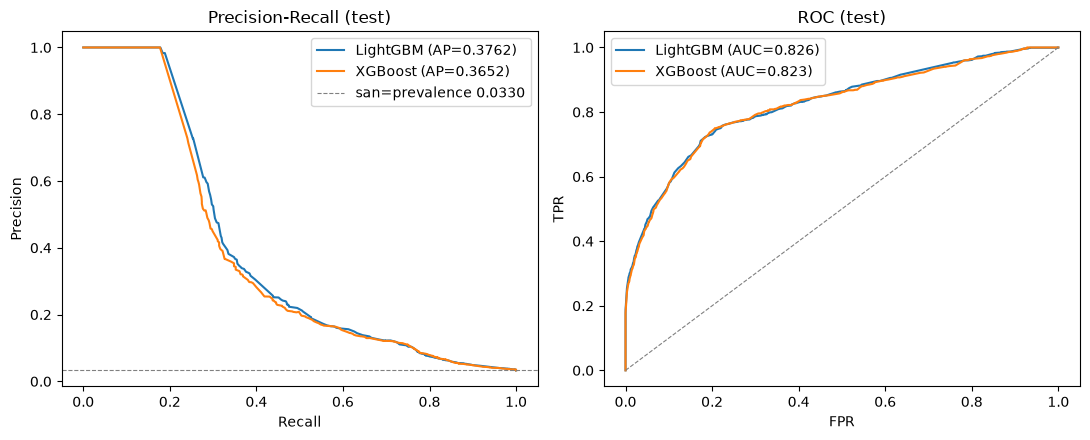

In [9]:
if proba:
    try:
        import matplotlib.pyplot as plt

        ytest = splits["test"]["isFraud"].to_numpy()
        prevalence = ytest.mean()
        fig, (axpr, axroc) = plt.subplots(1, 2, figsize=(11, 4.5))
        for m in proba:
            pr, rc, _ = precision_recall_curve(ytest, proba[m]["test"])
            ap = average_precision_score(ytest, proba[m]["test"])
            axpr.plot(rc, pr, label=f"{m} (AP={ap:.4f})")
            fpr, tpr, _ = roc_curve(ytest, proba[m]["test"])
            auc = roc_auc_score(ytest, proba[m]["test"])
            axroc.plot(fpr, tpr, label=f"{m} (AUC={auc:.3f})")
        axpr.axhline(
            prevalence, ls="--", c="grey", lw=0.8, label=f"san=prevalence {prevalence:.4f}"
        )
        axpr.set_xlabel("Recall")
        axpr.set_ylabel("Precision")
        axpr.set_title("Precision-Recall (test)")
        axpr.legend()
        axroc.plot([0, 1], [0, 1], ls="--", c="grey", lw=0.8)
        axroc.set_xlabel("FPR")
        axroc.set_ylabel("TPR")
        axroc.set_title("ROC (test)")
        axroc.legend()
        fig.tight_layout()
        plt.show()
    except ImportError:
        print("matplotlib unavailable; dung bang o tren.")
else:
    print("Skipped: enable RUN_COMPARISON above.")

📖 **Cell dưới — Metric NGÂN SÁCH (precision@k / recall@k).** Giả sử đội review chỉ soi được **top 0.1% / 0.5% / 1%** giao dịch điểm cao nhất mỗi kỳ. Bảng cho biết ở mỗi ngân sách, bắt được bao nhiêu % fraud (`recall_at_k`) và tỷ lệ trúng (`precision_at_k`). Đây là ngôn ngữ mà nghiệp vụ hiểu ngay.

In [10]:
budget_table = None
if proba:
    ytest = splits["test"]["isFraud"].to_numpy()
    rows = []
    for m in proba:
        for k in (0.001, 0.005, 0.01):
            rows.append({"model": m, **pr_at_k(ytest, proba[m]["test"], k)})
    budget_table = pd.DataFrame(rows)
    display(budget_table)
else:
    print("Skipped: enable RUN_COMPARISON above.")

,model,k_frac,k,precision_at_k,recall_at_k
0,LightGBM,0.001,37,1.000000,0.029553
1,LightGBM,0.005,189,1.000000,0.150958
2,LightGBM,0.010,379,0.767810,0.232428
3,XGBoost,0.001,37,1.000000,0.029553
4,XGBoost,0.005,189,1.000000,0.150958
5,XGBoost,0.010,379,0.765172,0.231629


## Phần C · Có nên thử nghiệm split không? — CÓ, và đây là cách đúng

Câu hỏi rất đúng. Ba mức, từ tối thiểu tới chắc chắn:

1. **Bắt buộc — temporal 3-way** (đang làm): train/val/test theo thời gian. Random split là **sai** (rò rỉ tương lai). Chọn ngưỡng ở val, đo ở test.
2. **Nên làm — rolling/expanding-window temporal CV** (cell dưới): trượt cửa sổ thời gian tạo **nhiều fold** train→test. Một split cho **một** con số; nhiều fold cho **phân phối** PR-AUC → biết kết quả *ổn định* hay *may rủi*. Đây là câu trả lời cho lo ngại "1 seed, 1 split" ở notebook 09.
3. **Khi cần chốt contract** — chạy ma trận này trong `training/` với manifest + đa seed, không phải notebook.

📖 **Cell dưới — Expanding-window CV nhẹ cho LightGBM:** 4 fold, mỗi fold train tới mốc `t`, test khối thời gian kế tiếp. In PR-AUC từng fold + trung bình ± lệch chuẩn.

In [11]:
cv_table = None
if frame is not None:
    import lightgbm as lgb

    folds = [(360, 420), (420, 500), (500, 580), (580, 660)]
    max_step = frame["step"].max()
    rows = []
    for cut, end in folds:
        if end > max_step:
            continue
        tr = frame[frame["step"] <= cut]
        te = frame[(frame["step"] > cut) & (frame["step"] <= end)]
        p = int((tr["isFraud"] == 1).sum())
        n = int((tr["isFraud"] == 0).sum())
        spw = float(np.sqrt(n / max(p, 1)))  # cung cau hinh cong bang nhu cell train
        mdl = lgb.LGBMClassifier(
            objective="binary",
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            min_child_samples=50,
            reg_lambda=1.0,
            scale_pos_weight=spw,
            deterministic=True,
            force_row_wise=True,
            seed=SEED,
            n_jobs=-1,
            verbose=-1,
        )
        mdl.fit(tr[FEATURES], tr["isFraud"])
        sc = mdl.predict_proba(te[FEATURES])[:, 1]
        rows.append(
            {
                "train_<=step": cut,
                "test_window": f"({cut},{end}]",
                "test_rows": len(te),
                "test_fraud": int(te["isFraud"].sum()),
                "pr_auc": round(float(average_precision_score(te["isFraud"], sc)), 6),
            }
        )
    cv_table = pd.DataFrame(rows)
    display(cv_table)
    if len(cv_table):
        print(
            f"PR-AUC qua {len(cv_table)} fold: mean={cv_table['pr_auc'].mean():.6f}  std={cv_table['pr_auc'].std():.6f}"
        )
else:
    print("Skipped: enable RUN_COMPARISON above.")

,train_<=step,test_window,test_rows,test_fraud,pr_auc
0,360,"(360,420]",353511,724,0.241984
1,420,"(420,500]",27370,820,0.528088
2,500,"(500,580]",56870,866,0.236805
3,580,"(580,660]",35249,870,0.325575


PR-AUC qua 4 fold: mean=0.333113  std=0.136201


📖 **Cách đọc CV**
- **`std` nhỏ** so với `mean` → kết quả *ổn định qua thời gian*, tin được. **`std` lớn** → PR-AUC dao động mạnh theo giai đoạn → một con số đơn lẻ (như ở test 3-way) chỉ là *may rủi của một khúc thời gian*.
- Prevalence mỗi fold (`test_fraud/test_rows`) khác nhau → nhắc lại vì sao PR-AUC (gắn với prevalence) phải đọc kèm bối cảnh, không so tuyệt đối giữa các fold một cách ngây thơ.

## Kết luận & bước tiếp
- **Chọn model bằng PR-AUC** (chính) + **recall@FPR=1%** và **precision@k** (nghiệp vụ); dùng **Brier/log loss** để kiểm xác suất có đáng tin không. Bỏ accuracy.
- **LightGBM vs XGBoost:** điền verdict sau khi chạy — kỳ vọng sát nhau; XGBoost chỉ là learning baseline, **không thay** LightGBM (họ đã khóa ADR-003).
- **Split:** temporal 3-way là tối thiểu bắt buộc; expanding-window CV cho biết độ ổn định. Bản chốt chạy ở `training/` với manifest + đa seed.
- Đây là surface **exploratory**; mọi quyết định promotable phải qua `training/` + gate.

## (tuỳ chọn) Ghi vào MLflow — nhật ký lab exploratory

📖 **Nên nối MLflow không? CÓ** — để so params/metric/nhiều lần chạy trực quan (bạn đã bật server ở http://127.0.0.1:5000), và plan Sprint 3 Ngày 2 cũng yêu cầu "log mỗi run vào MLflow". Nhưng vì đây là surface **exploratory**, phải tách khỏi bằng chứng promotable — 2 quy tắc:

- **Experiment riêng** `pit-fintech-notebook-exploration` — KHÔNG ghi vào experiment chính thức của `src/` (tránh lẫn với baseline đã khóa).
- Mọi run gắn tag `surface=notebook-exploratory`, `manifest_backed=false` → không ai nhầm nó là "verified". Bản chốt (manifest + gate) vẫn chạy ở `training/` (hard rule #4). MLflow ở đây chỉ là *nhật ký lab*.

> ⚠️ **Trước khi bật `LOG_TO_MLFLOW=True`:** kết quả LGB-vs-XGB hiện tại **chưa công bằng** (xem cảnh báo dưới bảng ngưỡng). Đừng log số gây hiểu nhầm — xử lý fairness (khớp regularization / tune) rồi mới log, kẻo MLflow lưu lại "XGBoost thắng 5×" sai lệch.

📖 **Cell dưới:** mặc định `LOG_TO_MLFLOW=False` (notebook vẫn chạy khi không có server). Bật `True` → tạo 1 parent run + mỗi model 1 nested run, log params + metric (PR-AUC, recall@FPR, precision@k, confusion matrix) vào experiment exploratory.

In [12]:
# Ghi so-model vào MLflow như NHẬT KÝ LAB exploratory — KHÔNG phải bằng chứng gate.
LOG_TO_MLFLOW = True  # server đang bật ở 127.0.0.1:5000
MLFLOW_TRACKING_URI = "http://127.0.0.1:5000"
MLFLOW_EXPERIMENT = "pit-fintech-notebook-exploration"  # experiment RIENG, khong dung cua src/

if LOG_TO_MLFLOW and proba:
    try:
        import mlflow
    except ImportError:
        mlflow = None
        print(
            "mlflow khong co trong kernel -> bo qua. Chay notebook trong env group training (lab-training)."
        )

    if mlflow is not None:
        import subprocess

        yval = splits["val"]["isFraud"].to_numpy()
        ytest = splits["test"]["isFraud"].to_numpy()
        try:
            commit = subprocess.check_output(
                ["git", "rev-parse", "--short", "HEAD"], text=True
            ).strip()
        except Exception:
            commit = "unknown"

        mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
        mlflow.set_experiment(MLFLOW_EXPERIMENT)
        with mlflow.start_run(run_name="nb10-model-comparison"):
            mlflow.set_tags(
                {
                    "surface": "notebook-exploratory",
                    "manifest_backed": "false",  # KHONG phai bang chung verified
                    "notebook": "10_model_comparison_metrics",
                    "git_commit": commit,
                }
            )
            mlflow.log_params(
                {
                    "seed": SEED,
                    "n_features": len(FEATURES),
                    "features": ",".join(FEATURES),
                    "split": "temporal train<=520 / val<=631 / test>=632",
                    "scale_pos_weight": round(float(globals().get("spw", 0.0)), 4),
                    "reg_lambda": globals().get("REG_LAMBDA"),
                }
            )
            for m in proba:
                with mlflow.start_run(run_name=m, nested=True):
                    mlflow.set_tags(
                        {"model": m, "surface": "notebook-exploratory", "manifest_backed": "false"}
                    )
                    sel = recall_at_fpr(yval, proba[m]["val"], 0.01)
                    te = at_threshold(ytest, proba[m]["test"], sel["threshold"])
                    mets = {
                        f"test_{k}": v for k, v in threshold_free(ytest, proba[m]["test"]).items()
                    }
                    mets["val_recall_at_fpr01"] = sel["recall_at_fpr"]
                    mets.update(
                        {
                            "test_precision": te["precision"],
                            "test_recall": te["recall"],
                            "test_f1": te["f1"],
                            "test_FP": te["FP"],
                        }
                    )
                    for k in (0.001, 0.005, 0.01):
                        pk = pr_at_k(ytest, proba[m]["test"], k)
                        mets[f"precision_at_{int(k * 1000)}permil"] = pk["precision_at_k"]
                        mets[f"recall_at_{int(k * 1000)}permil"] = pk["recall_at_k"]
                    mlflow.log_metric("threshold_fpr01", round(sel["threshold"], 6))
                    mlflow.log_metrics(mets)
        print(f"Logged -> experiment '{MLFLOW_EXPERIMENT}' @ {MLFLOW_TRACKING_URI}")
else:
    print("MLflow tat (LOG_TO_MLFLOW=False) hoac chua co proba.")

C:\workspace\pit-fintech\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🏃 View run LightGBM at: http://127.0.0.1:5000/#/experiments/6/runs/1e2e74ae86d040e5aacf44e0d3c078cc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6
🏃 View run XGBoost at: http://127.0.0.1:5000/#/experiments/6/runs/f19e550f366f40e481c06ca9a1ae9a40
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6
🏃 View run nb10-model-comparison at: http://127.0.0.1:5000/#/experiments/6/runs/498353b69d1a426aa4977a7cb57954f0
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6
Logged -> experiment 'pit-fintech-notebook-exploration' @ http://127.0.0.1:5000
